In [ ]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine

# 1. Setup the connection
load_dotenv()
DB_URI = os.getenv("SUPABASE_DB_URL")
engine = create_engine(DB_URI)

# 2. Pull'shredded' tables into DataFrames
df = pd.read_sql("SELECT * FROM telco_customer.stg_churn_cleaned", engine)

# Look at the data in the same window
df.head(10)

,customer_id,gender,senior_citizen,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,...,tech_support,streaming_tv,streaming_movies,tenure,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,False,True,False,False,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,True,Electronic check,29.85,29.85,False
1,5575-GNVDE,Male,False,False,False,True,No,DSL,Yes,No,...,No,No,No,34,One year,False,Mailed check,56.95,1889.50,False
2,3668-QPYBK,Male,False,False,False,True,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,True,Mailed check,53.85,108.15,True
3,7795-CFOCW,Male,False,False,False,False,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,False,Bank transfer (automatic),42.30,1840.75,False
4,9237-HQITU,Female,False,False,False,True,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,True,Electronic check,70.70,151.65,True
5,9305-CDSKC,Female,False,False,False,True,Yes,Fiber optic,No,No,...,No,Yes,Yes,8,Month-to-month,True,Electronic check,99.65,820.50,True
6,1452-KIOVK,Male,False,False,True,True,Yes,Fiber optic,No,Yes,...,No,Yes,No,22,Month-to-month,True,Credit card (automatic),89.10,1949.40,False
7,6713-OKOMC,Female,False,False,False,False,No phone service,DSL,Yes,No,...,No,No,No,10,Month-to-month,False,Mailed check,29.75,301.90,False
8,7892-POOKP,Female,False,True,False,True,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,28,Month-to-month,True,Electronic check,104.80,3046.05,True
9,6388-TABGU,Male,False,False,True,True,No,DSL,Yes,Yes,...,No,No,No,62,One year,False,Bank transfer (automatic),56.15,3487.95,False


# EDA for the Telco Churn Table

In [7]:
# Check for missing values and data types
print(df.isnull().sum())
df.info()

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
tenure               0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7032 non-null   object 
 1   gender             7032 non-null   object 
 2   senior_citizen     7032 non-null   bool   
 3   partner            7032 non-null   bool   
 4   dependents         7032 non-null   bool   
 5   phone_service      7032 non-null   bool   
 6   multiple

In [ ]:
# Calculate the Yes/No ratio (%) for senior_citizen, partner, and dependents.
# Each boolean column is normalised to percentages and displayed as a summary table
# with one row per feature and two columns: Yes (%) and No (%).
cols = ['senior_citizen', 'partner', 'dependents']
result = {}
for col in cols:
    vc = df[col].value_counts(normalize=True).mul(100).round(2)
    vc.index = vc.index.map(lambda x: 'Yes' if x is True or x == 1 else 'No')
    result[col] = vc

pd.DataFrame(result).T.rename_axis('Feature')[['Yes', 'No']].rename(columns={'Yes': 'Yes (%)', 'No': 'No (%)'})

,Yes (%),No (%)
Feature,,
senior_citizen,16.24,83.76
partner,48.25,51.75
dependents,29.85,70.15


In [14]:
# Gender distribution: percentage of Male vs Female customers
df['gender'].value_counts(normalize=True).mul(100).round(2).rename('percentage (%)').rename_axis('gender').to_frame()

,percentage (%)
gender,
Male,50.47
Female,49.53


In [ ]:
# Churn rate (%) broken down by senior_citizen, partner, and dependents.
# For each feature, I group customers by Yes/No and calculate the mean churn rate.
cols = ['senior_citizen', 'partner', 'dependents']
rows = []
for col in cols:
    grouped = df.groupby(col)['churn'].mean().mul(100).round(2)
    grouped.index = grouped.index.map(lambda x: 'Yes' if x is True or x == 1 else 'No')
    for val, rate in grouped.items():
        rows.append({'feature': col, 'value': val, 'churn_rate (%)': rate})

pd.DataFrame(rows).pivot(index='feature', columns='value', values='churn_rate (%)')[['Yes', 'No']].rename_axis('Feature').rename_axis(None, axis=1)

# Senior citizens churn at nearly double the rate of non-seniors (41.68% vs 23.65%) — a strong signal.
# Customers without a partner or without dependents churn more, suggesting family ties correlate with higher retention.

,Yes,No
Feature,,
dependents,15.53,31.28
partner,19.72,32.98
senior_citizen,41.68,23.65


In [17]:
# Churn rate (%) by gender — groups customers by Male/Female and calculates the mean churn rate for each.
df.groupby('gender')['churn'].mean().mul(100).round(2).rename('churn_rate (%)').to_frame()

,churn_rate (%)
gender,
Female,26.96
Male,26.20


In [ ]:
# Churn rate (%) by phone_service and internet_service.
# phone_service is boolean (Yes/No); internet_service is categorical mapped to Yes (has internet) / No.
cols_map = {
    'phone_service': df['phone_service'].map({True: 'Yes', False: 'No'}),
    'internet_service': df['internet_service'].map(lambda x: 'No' if x == 'No' else 'Yes'),
}
rows = []
for feature, series in cols_map.items():
    grouped = df.groupby(series)['churn'].mean().mul(100).round(2)
    for val, rate in grouped.items():
        rows.append({'feature': feature, 'value': val, 'churn_rate (%)': rate})

pd.DataFrame(rows).pivot(index='feature', columns='value', values='churn_rate (%)')[['Yes', 'No']].rename_axis('Feature').rename_axis(None, axis=1)

# Customers with internet service churn at over 4× the rate of those without — internet service is a major churn driver worth investigating further (e.g. by service type: DSL vs Fiber optic).

,Yes,No
Feature,,
internet_service,31.86,7.43
phone_service,26.75,25.00


In [ ]:
# Average monthly_charges and total_charges broken down by internet_service type (DSL / Fiber optic / No).
(df.groupby('internet_service')[['monthly_charges', 'total_charges']]
   .mean()
   .round(2)
   .rename(columns={'monthly_charges': 'avg_monthly_charges', 'total_charges': 'avg_total_charges'})
   .rename_axis('internet_service')
   .sort_values('avg_monthly_charges'))

# Fiber optic customers pay significantly more — 57% higher monthly than DSL and over 4× more than no-internet customers. Combined with the high churn rate seen earlier, Fiber optic is both the most valuable and highest-risk segment.

,avg_monthly_charges,avg_total_charges
internet_service,,
No,21.08,665.22
DSL,58.09,2119.79
Fiber optic,91.50,3205.30


In [ ]:
# Churn rate (%) for each internet_service type: DSL, Fiber optic, and No internet.
(df.groupby('internet_service')['churn']
   .mean()
   .mul(100)
   .round(2)
   .rename('churn_rate (%)')
   .rename_axis('internet_service')
   .sort_values()
   .to_frame())

# Fiber optic customers churn at over 2× DSL and 5× no-internet customers — despite (or perhaps because of) paying the highest monthly charges. This makes Fiber optic the highest-priority segment for retention efforts.

,churn_rate (%)
internet_service,
No,7.43
DSL,19.00
Fiber optic,41.89


In [ ]:
# Average tenure (months) by internet_service type, sorted ascending.
(df.groupby('internet_service')['tenure']
   .mean()
   .round(2)
   .rename('avg_tenure (months)')
   .rename_axis('internet_service')
   .sort_values()
   .to_frame())

# Average tenure is surprisingly similar across all three groups — around 30–33 months. This means Fiber optic's high churn rate (41.89%) isn't driven by shorter-tenured customers; those customers are leaving at roughly the same stage as DSL and no-internet customers, reinforcing that the service type itself (not tenure) is linked to churn risk.

,avg_tenure (months)
internet_service,
No,30.67
DSL,32.89
Fiber optic,32.92


In [ ]:
# Churn rate (%) by contract type (Month-to-month / One year / Two year), sorted descending.
(df.groupby('contract')['churn']
   .mean()
   .mul(100)
   .round(2)
   .rename('churn_rate (%)')
   .rename_axis('contract')
   .sort_values(ascending=False)
   .to_frame())

# Month-to-month customers churn at 15× the rate of two-year contract holders. Contract type is likely the single strongest predictor of churn in this dataset — getting customers onto longer contracts is a key retention lever.

,churn_rate (%)
contract,
Month-to-month,42.71
One year,11.28
Two year,2.85


In [ ]:
# Churn rate (%) by payment method, sorted descending.
(df.groupby('payment_method')['churn']
   .mean()
   .mul(100)
   .round(2)
   .rename('churn_rate (%)')
   .rename_axis('payment_method')
   .sort_values(ascending=False)
   .to_frame())

# Electronic check customers churn at 3× the rate of automatic payment users. Automatic methods (bank transfer & credit card) have the lowest churn — likely because they reduce friction and missed payments. This is a strong retention signal: encouraging customers to switch to automatic payments could meaningfully reduce churn.

,churn_rate (%)
payment_method,
Electronic check,45.29
Mailed check,19.20
Bank transfer (automatic),16.73
Credit card (automatic),15.25


In [ ]:
# Churn rate for the high-risk segment:
#   - has a partner OR dependent
#   - Fiber optic internet
#   - Month-to-month contract
#   - Electronic check payment

segment = df[
    (df['partner'] | df['dependents']) &
    (df['internet_service'] == 'Fiber optic') &
    (df['contract'] == 'Month-to-month') &
    (df['payment_method'] == 'Electronic check')
]

churn_rate = segment['churn'].mean() * 100
total = len(segment)

print(f"Segment size : {total} customers")
print(f"Churn rate   : {churn_rate:.2f}%")

# This high-risk segment of 541 customers churns at 54.90% — more than double the overall churn rate (~26.5%). The combination of month-to-month contract + Fiber optic + electronic check is a strong churn predictor, making this group a top priority for targeted retention campaigns.

Segment size : 541 customers
Churn rate   : 54.90%


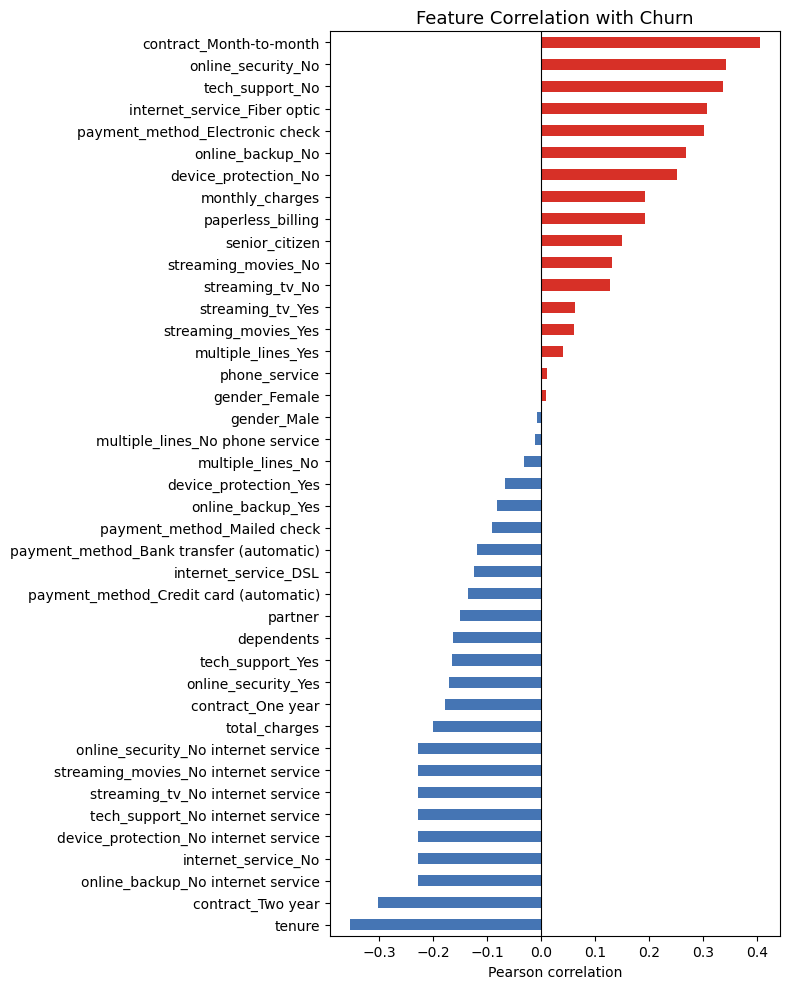

In [29]:
# --- Step 1: Feature correlation with churn ---
# One-hot encode categoricals, then compute point-biserial correlation with churn.
# This ranks every feature by how strongly it relates to churn — positive = higher churn risk.
import matplotlib.pyplot as plt

df_enc = pd.get_dummies(df.drop(columns='customer_id'), drop_first=False)
df_enc['churn'] = df_enc['churn'].astype(int)
corr = df_enc.corrwith(df_enc['churn']).drop('churn').sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn', fontsize=13)
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

Key Findings:
- Churn is primarily driven by contract length, tenure, and pricing.
- Customers on month-to-month contracts with high monthly charges and short tenure are most at risk.
- Add-on services and automatic payments act as stabilizing factors, while demographic variables contribute minimally.

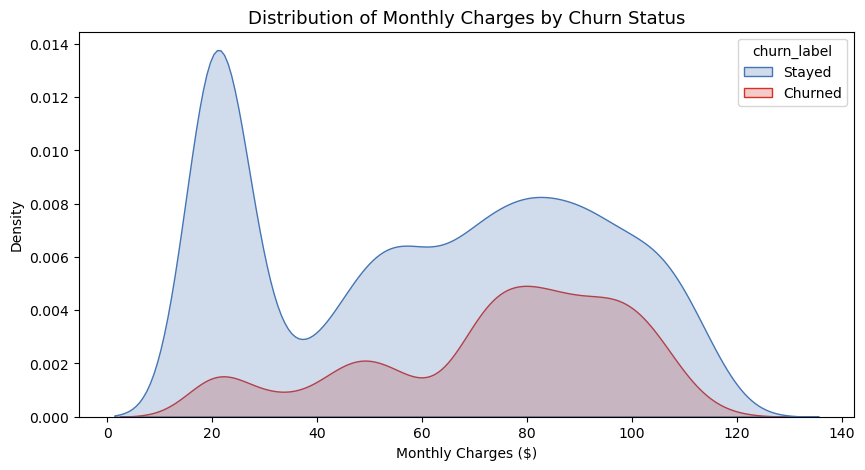

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use notebook column names as loaded from stg_churn_cleaned
plot_df = df.copy()
plot_df['churn_label'] = plot_df['churn'].map({True: 'Churned', False: 'Stayed'}).fillna(plot_df['churn'].astype(str))

plt.figure(figsize=(10, 5))
sns.kdeplot(data=plot_df, x='monthly_charges', hue='churn_label', fill=True, palette=['#4575b4', '#d73027'])

plt.title('Distribution of Monthly Charges by Churn Status', fontsize=13)
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.show()

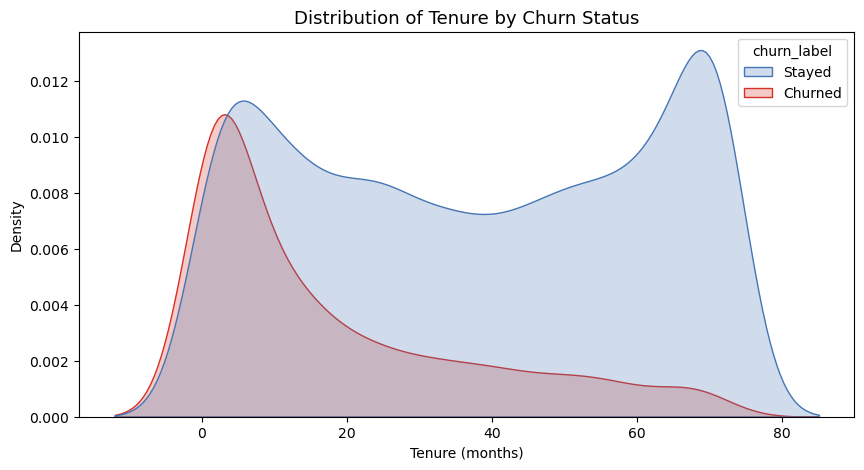

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use notebook column names as loaded from stg_churn_cleaned
plot_df = df.copy()
plot_df['churn_label'] = plot_df['churn'].map({True: 'Churned', False: 'Stayed'}).fillna(plot_df['churn'].astype(str))

plt.figure(figsize=(10, 5))
sns.kdeplot(data=plot_df, x='tenure', hue='churn_label', fill=True, palette=['#4575b4', '#d73027'])

plt.title('Distribution of Tenure by Churn Status', fontsize=13)
plt.xlabel('Tenure (months)')
plt.ylabel('Density')
plt.show()

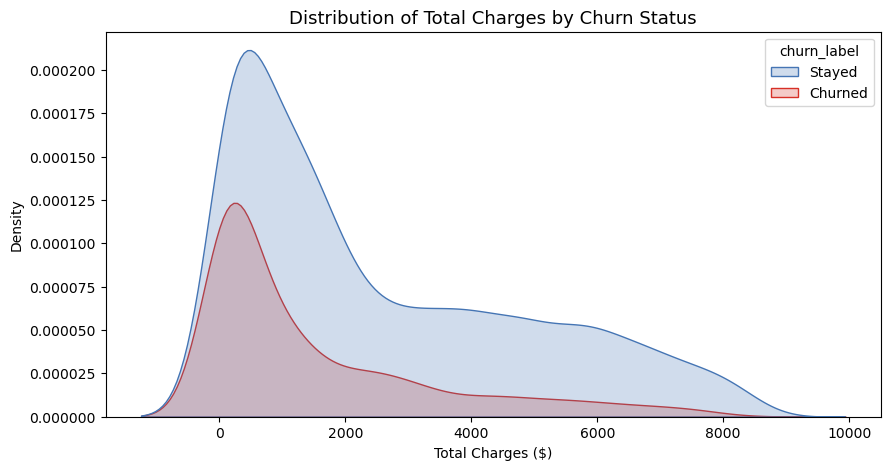

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use notebook column names as loaded from stg_churn_cleaned
plot_df = df.copy()
plot_df['churn_label'] = plot_df['churn'].map({True: 'Churned', False: 'Stayed'}).fillna(plot_df['churn'].astype(str))

plt.figure(figsize=(10, 5))
sns.kdeplot(data=plot_df, x='total_charges', hue='churn_label', fill=True, palette=['#4575b4', '#d73027'])

plt.title('Distribution of Total Charges by Churn Status', fontsize=13)
plt.xlabel('Total Charges ($)')
plt.ylabel('Density')
plt.show()

/var/folders/bg/bg6_lhk10cb2v0n9434vjxb80000gn/T/ipykernel_50502/3751745543.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_churn = df.groupby('Charge_Range')['Churn_Numeric'].mean().reset_index()
/var/folders/bg/bg6_lhk10cb2v0n9434vjxb80000gn/T/ipykernel_50502/3751745543.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Charge_Range', y='Churn_Numeric', data=bin_churn, palette='Reds_r')


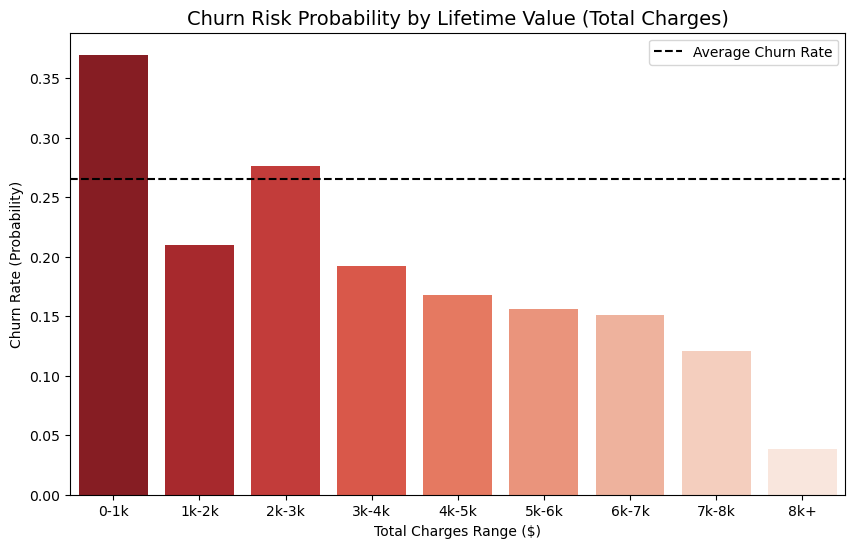

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure TotalCharges is numeric
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df['Churn_Numeric'] = df['churn'].apply(lambda x: 1 if str(x).lower() in ['yes', 'true', '1'] else 0)

# 2. Create Bins (0-1k, 1k-2k, etc.)
bins = [0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]
labels = ['0-1k', '1k-2k', '2k-3k', '3k-4k', '4k-5k', '5k-6k', '6k-7k', '7k-8k', '8k+']
df['Charge_Range'] = pd.cut(df['total_charges'], bins=bins, labels=labels)

# 3. Calculate Churn Rate per Bin
bin_churn = df.groupby('Charge_Range')['Churn_Numeric'].mean().reset_index()

# 4. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Charge_Range', y='Churn_Numeric', data=bin_churn, palette='Reds_r')

plt.title('Churn Risk Probability by Lifetime Value (Total Charges)', fontsize=14)
plt.ylabel('Churn Rate (Probability)')
plt.xlabel('Total Charges Range ($)')
plt.axhline(df['Churn_Numeric'].mean(), color='black', linestyle='--', label='Average Churn Rate')
plt.legend()
plt.show()

Key takaway: While Tenure is the primary driver of churn, the Total Charges analysis confirms that our highest financial risk occurs in the sub-$1,000 bracket, where the company has possibly yet to break even on customer acquisition costs.

## Hypotesis:

Based on the visual patterns and correlations identified, I will test the following hypotheses during the modeling phase:

The "Convenience vs. Commitment" Hypothesis: High churn in Month-to-Month contracts suggests that the lack of contractual "switching costs" makes customers highly reactive to competitor offers. I expect Contract_Month-to-month to be the strongest predictor.

The "Value-Service Paradox": Fiber Optic users churn at higher rates despite better speeds. I suspect this is due to the intersection of High Monthly Charges and a lack of stabilizing services like Tech Support.

The "Passive Loyalty" Effect: Customers on Automatic Credit Card/Bank Transfer payments are likely to have higher retention than those using Electronic Checks, as it removes the monthly "decision point" to pay or cancel.